# Generative Adversarial Nets (GAN)

$$
V(G,D)
=
\mathbb{E}_{x \sim p_{\text{data}}(x)}
[\log D(x)]
+
\mathbb{E}_{z \sim p_z(z)}
[\log(1-D(G(z)))]
$$

$$
=
\mathbb{E}_{x \sim p_{\text{data}}(x)}
[\log D(x)]
+
\mathbb{E}_{x \sim p_g(x)}
[\log(1-D(G(x)))]
$$

$$
V(G,D)
=
\int_x p_{\text{data}}(x)\log D(x)\,dx
+
\int_x p_g(x)\log(1-D(G(x)))\,dx
$$

For optimal discriminator,

$$
\frac{\partial V(G,D)}{\partial D(x)} = 0
$$

Therefore,

$$
\frac{\partial V(G,D)}{\partial D(x)}
=
\frac{p_{\text{data}}(x)}{D(x)}
-
\frac{p_g(x)}{1-D(x)}
=
0
$$

$$
\Rightarrow
\frac{p_{\text{data}}(x)}{D(x)}
=
\frac{p_g(x)}{1-D(x)}
$$

Hence,

$$
D^*(x)
=
\frac{
p_{\text{data}}(x)
}{
p_g(x)+p_{\text{data}}(x)
}
$$

Optimal discriminator:

If

$$
p_g(x)=p_{\text{data}}(x)
$$

then

$$
D^*(x)=\frac{1}{2}
$$

---

# Value Function at Optimal Discriminator

$$
V(G,D^*)
=
\int
p_{\text{data}}(x)
\log\left(\frac{1}{2}\right)dx
+
\int
p_g(x)
\log\left(\frac{1}{2}\right)dx
$$

$$
=
-\log 4
$$

Also,

$$
V(G,D^*)
=
\mathbb{E}_{x \sim p_{\text{data}}}
[-\log 2]
+
\mathbb{E}_{x \sim p_g}
[-\log 2]
$$

$$
=
-\log 4
$$

---

# Expanding the Objective

$$
V(G,D^*)
=
\int
p_{\text{data}}(x)
\log
\left(
\frac{
p_{\text{data}}(x)
}{
\frac{
p_{\text{data}}(x)+p_g(x)
}{2}
}
\right)
dx
+
\int
p_g(x)
\log
\left(
\frac{
p_g(x)
}{
\frac{
p_{\text{data}}(x)+p_g(x)
}{2}
}
\right)
dx
$$

$$
=
KL
\left(
p_{\text{data}}(x)
\;\Bigg\|\;
\frac{
p_{\text{data}}(x)+p_g(x)
}{2}
\right)
+
KL
\left(
p_g(x)
\;\Bigg\|\;
\frac{
p_{\text{data}}(x)+p_g(x)
}{2}
\right)
-
\log 4
$$

$$
=
-\log 4
+
2 \cdot
JSD
\left(
p_{\text{data}}
\|p_g
\right)
$$

---

# Jensen Shannon Divergence

$$
JSD(p\|q)
=
\frac{1}{2}
D_{KL}
\left(
p
\;\Bigg\|\;
\frac{p+q}{2}
\right)
+
\frac{1}{2}
D_{KL}
\left(
q
\;\Bigg\|\;
\frac{p+q}{2}
\right)
$$

Therefore,

$$
V(G,D^*)
=
-\log 4
+
2JSD(p_{\text{data}}\|p_g)
$$

---

# Gradients

Given samples:

$$
x
\sim
\left(
x^{(1)},
x^{(2)},
x^{(3)},
\dots,
x^{(m)}
\right)
$$

$$
z
\sim
\left(
z^{(1)},
z^{(2)},
z^{(3)},
\dots,
z^{(m)}
\right)
$$

Objective:

$$
V(G,D)
=
\mathbb{E}_{x \sim p_{\text{data}}}
[\log D(x)]
+
\mathbb{E}_{z \sim p_z}
[\log(1-D(G(z)))]
$$

---

# Monte Carlo Approximation

$$
V(G,D)
=
\frac{1}{m}
\sum_{i=1}^{m}
\log D(x^{(i)})
+
\frac{1}{m}
\sum_{i=1}^{m}
\log
\left(
1-D(G(z^{(i)}))
\right)
$$

Where:

- $D(x)$ → Neural network with parameters $\theta_d$
- $G(z)$ → Neural network with parameters $\theta_g$

Thus,

$$
V(G,D)
=
\frac{1}{m}
\sum_{i=1}^{m}
\log D(x^{(i)};\theta_d)
+
\frac{1}{m}
\sum_{i=1}^{m}
\log
\left(
1-
D(G(z^{(i)};\theta_g);\theta_d)
\right)
$$

---

# Gradient w.r.t. Discriminator

$$
\nabla_{\theta_d}V(G,D)
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
\frac{
\nabla_{\theta_d}D(x^{(i)};\theta_d)
}{
D(x^{(i)};\theta_d)
}
-
\frac{
\nabla_{\theta_d}
D(G(z^{(i)};\theta_g);\theta_d)
}{
1-D(G(z^{(i)};\theta_g);\theta_d)
}
\right)
$$

---

# Gradient w.r.t. Generator

$$
\nabla_{\theta_g}V(G,D)
=
-
\frac{1}{m}
\sum_{i=1}^{m}
\frac{
\nabla_{\theta_g}
D(G(z^{(i)};\theta_g);\theta_d)
\cdot
\nabla_{\theta_g}
G(z^{(i)};\theta_g)
}{
1-D(G(z^{(i)};\theta_g);\theta_d)
}
$$

In [1]:
import torch
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Linear Layer Implementation
class LinearLayer(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.weights = nn.Parameter(torch.rand(in_features, out_features))
        self.bias = nn.Parameter(torch.ones(out_features))
        nn.init.xavier_uniform_(self.weights)
    
    def forward(self, x: torch.Tensor):
        return x @ self.weights + self.bias

# Layer Norm
class LayerNorm(nn.Module):
    def __init__(self, in_features: int, eps: float = 1e-3):
        super().__init__()
        self.scale = nn.Parameter(torch.rand(in_features))
        self.shift = nn.Parameter(torch.zeros(in_features))
        self.eps = eps
    
    def forward(self, x: torch.Tensor):
        x_mean = x.mean(dim = -1, keepdim=True)
        x_var = x.var(dim = -1, keepdim=True, unbiased = False)
        x_norm = (x - x_mean) / torch.sqrt(x_var + self.eps)
        return self.scale * x_norm + self.shift

class GeneratorBlock(nn.Module):
    def __init__(self, in_feature: int, out_feature: int):
        super().__init__()
        self.block = nn.Sequential(
            LinearLayer(in_features = in_feature, out_features = out_feature),
            LayerNorm(in_features = out_feature),
            nn.Tanh()
        )

    def forward(self, x: torch.Tensor):
        return self.block(x)
    
class DiscriminatorBlock(nn.Module):
    def __init__(self, in_feature: int, out_feature: int):
        super().__init__()
        self.block = nn.Sequential(
            LinearLayer(in_features = in_feature, out_features = out_feature),
            nn.LeakyReLU(negative_slope = 0.2)
        )

    def forward(self, x: torch.Tensor):
        return self.block(x)

class Generator(nn.Module):
    """
    This class implements the core Generator framework,
        - where the 'Generator' only sees the random latent vector sampled from the known distribution (Gaussian in our case)
        - where the 'Discriminator' sees both the fake image generated by the 'Generator' and the real image

    Note: The generator NEVER directly sees: labels, image classes, semantic meaning, etc. It only sees gradients from the discriminator
    """
    def __init__(self, in_features: int, hidden_dim: int, out_features: int, n_layers: int):
        super().__init__()
        self.generator = [GeneratorBlock(in_features, hidden_dim)]

        # Inititalize Layers as [Linear()--> LayerNorm() --> Tanh()] x n
        for _ in range(n_layers - 1):
            self.generator.append(GeneratorBlock(hidden_dim, hidden_dim))
        
        # Append the final layer in the Network, usually GAN removes the LayerNorm at the final stage of the transformations
        self.generator.append(
            nn.Sequential(LinearLayer(hidden_dim, out_features), nn.Tanh())
        )

        # Unpack and send it to sequential
        self.generator = nn.Sequential(*self.generator)
    
    def forward(self, x: torch.Tensor):
        return self.generator(x)

class Discriminator(nn.Module):
    """
    This class implements the core Discriminator framework,
        - where the 'Generator' only sees the random latent vector sampled from the known distribution (Gaussian in our case)
        - where the 'Discriminator' sees both the fake image generated by the 'Generator' and the real image

    Note: The generator NEVER directly sees: labels, image classes, semantic meaning, etc. It only sees gradients from the discriminator
    """
    def __init__(self, in_features: int, hidden_dim: int, out_features: int, n_layers: int):
        super().__init__()
        self.discriminator = [DiscriminatorBlock(in_features, hidden_dim)]

        # Inititalize Layers as [Linear()--> LayerNorm() --> Tanh()] x n
        for _ in range(n_layers - 1):
            self.discriminator.append(DiscriminatorBlock(hidden_dim, hidden_dim))
        
        # Append the final layer in the Discriminator Network
        self.discriminator.append(
            nn.Sequential(
                LinearLayer(hidden_dim, hidden_dim),

            )
        )

        # Unpack and send it to sequential
        self.discriminator = nn.Sequential(*self.discriminator)
    
    def forward(self, x: torch.Tensor):
        return self.discriminator(x) # NOTE: I didn't used sigmoid here, i'll later use `nn.BCEWithLogitsLoss()``

## Load the Image

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
    
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root="../data/celeba",
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

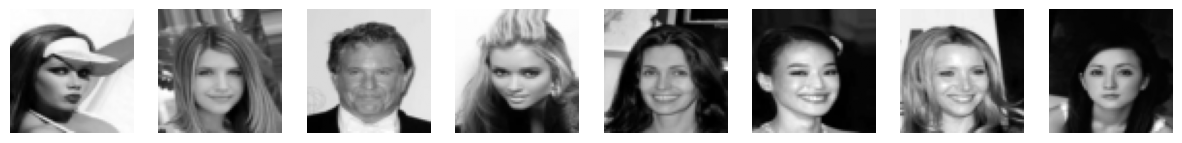

In [4]:
import matplotlib.pyplot as plt

images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 8, figsize=(15,3))

for i in range(8):
    axes[i].imshow(images[i].permute(1,2,0), cmap = "grey")
    axes[i].axis("off")

plt.show()

## Build the Model

In [5]:
BATCH_SIZE = 64
IN_FEATURES = images.view(BATCH_SIZE, -1).shape[-1]
LATENT_DIMS = 128
HIDDEN_DIMS = 128
N_G_LAYERS = 4
N_D_LAYERS = 3
EPOCHS = 100

g_lr = 2e-4
d_lr = 2e-4

K = 1

# Define two competing models
G = Generator(in_features = LATENT_DIMS, hidden_dim = HIDDEN_DIMS, out_features = IN_FEATURES, n_layers = N_G_LAYERS)
D = Discriminator(in_features = IN_FEATURES, hidden_dim = HIDDEN_DIMS, out_features = 1, n_layers = N_D_LAYERS)
g_optimizer = torch.optim.Adam(G.parameters(), lr = g_lr) # Optimizer to train the Generator's Network
d_optimizer = torch.optim.Adam(D.parameters(), lr = d_lr) # Optimizer to train the Discriminator's Network

## Experiment Tracking

In [6]:
import wandb

wandb.init(
    project="VannilaMLPGAN-celeba",
    name=f"run_lr{g_optimizer.param_groups[0]['lr']}",
    config={
        "g_lr": g_optimizer.param_groups[0]['lr'],
        "d_lr": d_optimizer.param_groups[0]['lr'],
        "epochs": EPOCHS,
        "batch_size": loader.batch_size,
        "latent_dims": LATENT_DIMS,
        "K": K,
        "generator_parameters": sum(p.numel() for p in G.parameters()),
        "discriminator_parameters": sum(p.numel() for p in D.parameters()),
        "Generator Architecture": str(G),
        "Discriminator Architecture": str(D)
    }
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Himanshu Singh\_netrc.
wandb: Currently logged in as: himanshusr451tehs (himanshusr451tehs-personaluse-com) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Train the Model

In [7]:
import torch
import torch.nn as nn
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import tqdm

print(f"Training on device = [{device}]")

G.to(device)
D.to(device)

G.train()
D.train()

loss_fn = nn.BCEWithLogitsLoss()

global_step = 0

# Fixed latent vector for monitoring progression
fixed_z = torch.randn(16, LATENT_DIMS, device=device)


# Training Loop
for epoch in range(EPOCHS):

    progress_bar = tqdm.tqdm(
        loader,
        desc=f"Epoch [{epoch+1}/{EPOCHS}]",
        leave=False
    )

    epoch_d_loss = 0.0
    epoch_g_loss = 0.0

    for images, _ in progress_bar:

        images = images.to(device)

        # Flatten image for MLP GAN
        images = images.view(images.shape[0], -1)
        B = images.shape[0] # get the batch_dim

        # Train Discriminator: Maximze: log(D(x)) + log(D(G(z)))
        for _ in range(K):# Train the Discriminator 'K' times and then train the Generator once
            # This is mentioned in the original paper: 'Generative Adversarial Nets' link: https://arxiv.org/pdf/1406.2661
            z = torch.randn(B, LATENT_DIMS, device=device) # sample a random latent vector from gaussian distribution

            fake_img = G(z).detach() # using 'detach()' because i don't want to update generator's parameter while backpropogating through discriminator

            # see what the discriminator is thinking about the generated fake image
            d_real_score = D(images) # Getting the score of real images from the discriminator
            d_fake_score = D(fake_img) # Getting the score of fake images (generated by the generator) from the discriminator

            # Get the discriminator's loss
                # This should contain 2 terms, one for correctly classifying the fake image and one for correctly classifying the real image
                # Real image: target = 0
                # Fake image: target = 1
            d_loss = ( 
                loss_fn(
                    d_real_score,
                    torch.ones_like(d_real_score) # we want discriminator to correctly classify real image as 1
                )
                +
                loss_fn(
                    d_fake_score,
                    torch.zeros_like(d_fake_score) # we want discriminator to correctly classify fake image as 0
                )
            )

            # Optimize the discriminator
            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()
    
        # Train Generator: maximize: log(D(G(z)))
        z = torch.randn(B, LATENT_DIMS, device=device)
        fake_img = G(z)

        # see what the discriminator is thinking about the generated fake image
        d_fake_score = D(fake_img)
        g_loss = loss_fn(
            d_fake_score,
            torch.ones_like(d_fake_score) # Generator wants the discriminator to classify the fake image as Real (1), because then it would be realistic
        )

        # Optimize the Generator
        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # ---------------------------------------------------- Logging ----------------------------------------------------------------------------------
        # Accumulate Epoch Loss
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

        # Progress Bar Update
        progress_bar.set_postfix({
            "D Loss": f"{d_loss.item():.4f}",
            "G Loss": f"{g_loss.item():.4f}"
        })

        # WandB Batch Logging
        wandb.log({
            "Discriminator Loss": d_loss.item(),
            "Generator Loss": g_loss.item(),
            "Global Step": global_step
        })

        global_step += 1

    # Epoch Average Loss
    avg_d_loss = epoch_d_loss / len(loader)
    avg_g_loss = epoch_g_loss / len(loader)

    print(
        f"[EPOCH {epoch+1}/{EPOCHS}] "
        f"D Loss: {avg_d_loss:.5f} | "
        f"G Loss: {avg_g_loss:.5f}"
    )

    # Generate & Log Images Every 5 Epochs
    if epoch % 5 == 0:
        G.eval()
        with torch.no_grad():
            fake_imgs = G(fixed_z)

            # Reshape back to image format
            fake_imgs = fake_imgs.view(-1, 1, 64, 64)

            # Convert [-1,1] (logits) -> [0,1] (image range)
            # fake_imgs = (fake_imgs + 1) / 2
            # fake_imgs = fake_imgs.clamp(0, 1)

            # Create image grid
            grid = vutils.make_grid(
                fake_imgs,
                nrow=4,
                normalize=False
            )

            # Convert CHW (pytorch's view) -> HWC (matplotlib's view)
            grid = grid.permute(1, 2, 0).cpu().numpy()

            # Log image to wandb
            wandb.log({
                "Generated Images": wandb.Image(
                    grid,
                    caption=f"Epoch {epoch}"
                ),
                "Epoch": epoch,
                "Average D Loss": avg_d_loss,
                "Average G Loss": avg_g_loss
            })
        G.train()
wandb.finish()

Training on device = [cuda]


wandb: WARNING Data passed to `wandb.Image` should consist of values in the range [0, 255], image data will be normalized to this range, but behavior will be removed in a future version of wandb.


[EPOCH 1/100] D Loss: 0.90848 | G Loss: 2.27041


[EPOCH 2/100] D Loss: 0.43400 | G Loss: 3.29031


[EPOCH 3/100] D Loss: 0.41401 | G Loss: 4.53128


...

[EPOCH 97/100] D Loss: 0.81345 | G Loss: 2.08972


[EPOCH 98/100] D Loss: 0.85569 | G Loss: 2.13916


[EPOCH 99/100] D Loss: 0.92147 | G Loss: 2.05544


[EPOCH 100/100] D Loss: 1.05038 | G Loss: 2.25650


Average D Loss,▇▁▁▃▅▄▅▅▇▆▆█▇▆▅▆▆▆█▆
Average G Loss,▂▇█▄▃▄▂▃▃▃▂▂▃▂▃▃▂▁▂▁
Discriminator Loss,▁▁▁▁▅▂▂▂▂▅▅▅▃▃▅▄▂▃█▅▄▄▅▆▅▄▅▅▃▄▆▄▅▅▅▅▅▆▄▇
Epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
Generator Loss,███▃▄▄▄▄▄▄▆▄▆▄▅▃▄▅▂▆▃▂▆▆▂▂▂▅▂▂▄▆▄▅▃▃▂▃▁▅
Global Step,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇██
Average D Loss,0.79304
Average G Loss,1.95387
Discriminator Loss,0.76239
Epoch,95
Generator Loss,2.11544


## Sample from the Trained Generator

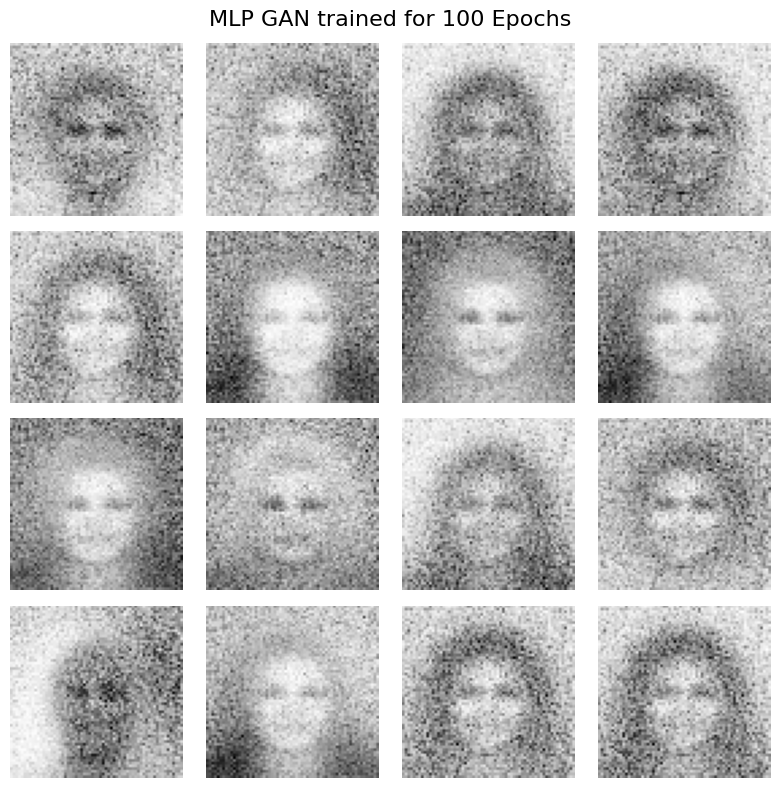

In [11]:
n_images = 120
z = torch.randn(n_images, LATENT_DIMS).to(device)

with torch.no_grad():
    fake_imgs = G(z)

fake_imgs = fake_imgs.view(n_images, 1, 64, 64)

fig, axes = plt.subplots(4, 4, figsize=(8,8))

for i, ax in enumerate(axes.flatten()):

    img = fake_imgs[i].cpu()
    img = img.permute(1,2,0)

    img = (img + 1) / 2
    img = img.clamp(0,1)

    ax.imshow(img, cmap="grey")
    ax.axis("off")

fig.suptitle("MLP GAN trained for 100 Epochs", fontsize=16)

plt.tight_layout()
plt.show()

## Save the Model

In [12]:
import torch
# Save GAN Checkpoint

checkpoint = {
    # Generator
    "generator_state_dict": G.state_dict(),
    "generator_optimizer_state_dict": g_optimizer.state_dict(),
    "generator_lr": g_optimizer.param_groups[0]["lr"],

    # Discriminator
    "discriminator_state_dict": D.state_dict(),
    "discriminator_optimizer_state_dict": d_optimizer.state_dict(),
    "discriminator_lr": d_optimizer.param_groups[0]["lr"],

    # Training Metadata
    "epoch": epoch,
    "latent_dims": LATENT_DIMS,
    "hidden_dims": HIDDEN_DIMS,
    "batch_size": BATCH_SIZE,
    "n_g_layers": N_G_LAYERS,
    "n_d_layers": N_D_LAYERS
}

# Save Checkpoint
torch.save(
    checkpoint,
    "../saved_models/vanilla_mlp_gan_1_channel_checkpoint.pth"
)

print("Checkpoint Saved Successfully!")

Checkpoint Saved Successfully!


## Load the Model

In [35]:
import torch


# Load Checkpoint
checkpoint = torch.load(
    "../saved_models/vanilla_mlp_gan_1_channel_checkpoint.pth",
    map_location=device
)

# Load Generator
G.load_state_dict(
    checkpoint["generator_state_dict"]
)
g_optimizer.load_state_dict(
    checkpoint["generator_optimizer_state_dict"]
)

# Load Discriminator
D.load_state_dict(
    checkpoint["discriminator_state_dict"]
)
d_optimizer.load_state_dict(
    checkpoint["discriminator_optimizer_state_dict"]
)

# Restore Metadata
start_epoch = checkpoint["epoch"]
g_lr = checkpoint["generator_lr"]
d_lr = checkpoint["discriminator_lr"]

print(f"Loaded Checkpoint From Epoch {start_epoch}")
print(f"Generator LR = {g_lr}")
print(f"Discriminator LR = {d_lr}")

C:\Users\Himanshu Singh\AppData\Local\Temp\ipykernel_13220\2611141527.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


RuntimeError: Error(s) in loading state_dict for Generator:
	size mismatch for generator.4.0.weights: copying a param with shape torch.Size([128, 4096]) from checkpoint, the shape in current model is torch.Size([128, 64]).
	size mismatch for generator.4.0.bias: copying a param with shape torch.Size([4096]) from checkpoint, the shape in current model is torch.Size([64]).

## Loading the model trained on 3 channels

In [45]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Checkpoint
checkpoint = torch.load(
    "../saved_models/vanilla_mlp_gan_checkpoint.pth",
    map_location=device
)

BATCH_SIZE = 64
# IN_FEATURES = images.view(BATCH_SIZE, -1).shape[-1]
IN_FEATURES = 12288
LATENT_DIMS = checkpoint["latent_dims"]
HIDDEN_DIMS = checkpoint["hidden_dims"]
N_G_LAYERS = checkpoint["n_g_layers"]
N_D_LAYERS = checkpoint["n_d_layers"]
EPOCHS = checkpoint["epoch"]

g_lr = checkpoint["generator_lr"]
d_lr = checkpoint["discriminator_lr"]
K = 1 

G = Generator(in_features = LATENT_DIMS, hidden_dim = HIDDEN_DIMS, out_features = IN_FEATURES, n_layers = N_G_LAYERS)
D = Discriminator(in_features = IN_FEATURES, hidden_dim = HIDDEN_DIMS, out_features = 1, n_layers = N_D_LAYERS)
G = G.to(device)
D = D.to(device)

# Load Generator
G.load_state_dict(
    checkpoint["generator_state_dict"]
)
g_optimizer.load_state_dict(
    checkpoint["generator_optimizer_state_dict"]
)

# Load Discriminator
D.load_state_dict(
    checkpoint["discriminator_state_dict"]
)
d_optimizer.load_state_dict(
    checkpoint["discriminator_optimizer_state_dict"]
)

# Restore Metadata
start_epoch = checkpoint["epoch"]
g_lr = checkpoint["generator_lr"]
d_lr = checkpoint["discriminator_lr"]


print(f"Loaded Checkpoint From Epoch {start_epoch}")
print(f"Generator LR = {g_lr}")
print(f"Discriminator LR = {d_lr}")

Loaded Checkpoint From Epoch 99
Generator LR = 0.0002
Discriminator LR = 0.0002


C:\Users\Himanshu Singh\AppData\Local\Temp\ipykernel_13220\2942137604.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


## Interpolating the Latent Space

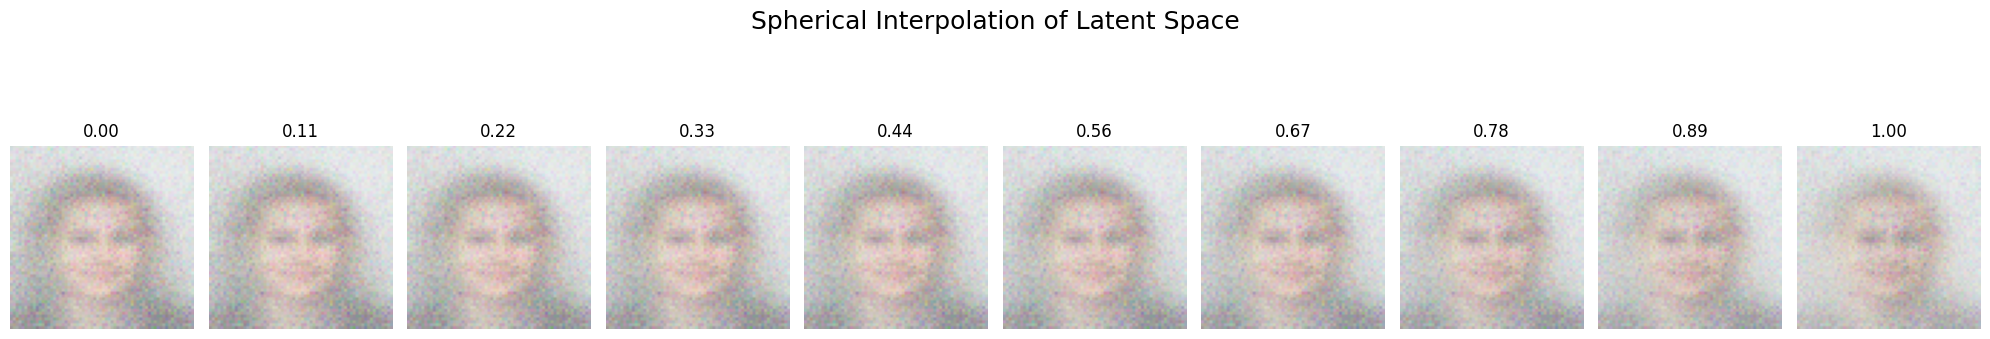

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


# SLERP FUNCTION
def slerp(z1, z2, t, threshold=0.9995):

    z1_norm = F.normalize(z1, dim=-1)
    z2_norm = F.normalize(z2, dim=-1)

    dot = (z1_norm * z2_norm).sum(dim=-1, keepdim=True)

    # Fallback to LERP if vectors are too close
    if torch.abs(dot).mean() > threshold:
        return (1 - t) * z1 + t * z2

    dot = torch.clamp(dot, -1.0, 1.0)

    theta = torch.acos(dot)

    sin_theta = torch.sin(theta)

    coeff1 = torch.sin((1 - t) * theta) / sin_theta
    coeff2 = torch.sin(t * theta) / sin_theta

    return coeff1 * z1 + coeff2 * z2

# GENERATE TWO LATENT VECTORS
z1 = torch.randn(1, LATENT_DIMS).to(device)
z2 = torch.randn(1, LATENT_DIMS).to(device)

# INTERPOLATION STEPS
steps = 10

fig, axes = plt.subplots(1, steps, figsize=(20, 4))

fig.suptitle(
    "Spherical Interpolation of Latent Space",
    fontsize=18
)


# GENERATE INTERPOLATED IMAGES
for i, t in enumerate(torch.linspace(0, 1, steps).to(device)):

    # SLERP interpolation
    z = slerp(z1, z2, t)

    with torch.no_grad():

        img = G(z)[0]

    img = img.detach().cpu()

    # Reshape flattened RGB vector
    img = img.reshape(3, 64, 64)

    # Normalize from [-1,1] -> [0,1]
    img = (img + 1) / 2

    # Convert CHW -> HWC
    img = img.permute(1, 2, 0)

    axes[i].imshow(img.numpy())

    axes[i].set_title(f"{t:.2f}")

    axes[i].axis("off")


plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()